# Solar Tracking System: Dual-Axis Angle Correction Prediction

This notebook trains a Machine Learning model on real IoT solar tracking telemetry (`solar_data.csv`) to predict dual-axis residual correction angles:
1. `ground_truth_azimuth_residual_deg`
2. `ground_truth_elevation_residual_deg`

### Deployment Pipeline Workflow:
$$\text{Sensor Data} \longrightarrow \text{ML Model} \longrightarrow \text{Azimuth Correction} \longrightarrow \text{Elevation Correction} \longrightarrow \text{Motor Control}$$


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

print("Imports completed successfully!")


Imports completed successfully!


### Step 1: Load and Clean Dataset
- Load `solar_data.csv`
- Drop duplicates and missing values
- Convert feature and target columns to numeric
- Filter out invalid / infinite values
- Inspect dataset shape before and after cleaning


In [2]:
# Load raw data
csv_path = "solar_data.csv"
df_raw = pd.read_csv(csv_path)
shape_before = df_raw.shape

# Define feature columns and target columns
feature_cols = [
    'time_sin', 'time_cos', 'Solar_Azimuth_deg', 'Solar_Elevation_deg',
    'Baseline_Azimuth_deg', 'Baseline_Elevation_deg', 'Top_LDR', 'Bottom_LDR',
    'Left_LDR', 'Right_LDR', 'Horizontal_Error', 'Vertical_Error',
    'Horizontal_Normalized', 'Vertical_Normalized', 'Lux', 'Temperature_C',
    'Humidity_percent', 'Voltage_V', 'Current_A', 'Power_W'
]

target_cols = [
    'ground_truth_azimuth_residual_deg',
    'ground_truth_elevation_residual_deg'
]

# 1. Remove duplicate rows
df_clean = df_raw.drop_duplicates().copy()

# 2. Convert columns to numeric & drop missing
for col in feature_cols + target_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 3. Remove infinite / invalid values
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()
shape_after = df_clean.shape

print(f"Dataset shape BEFORE cleaning: {shape_before}")
print(f"Dataset shape AFTER cleaning:  {shape_after}")
print(f"Total features used: {len(feature_cols)}")
print(f"Target columns: {target_cols}")
df_clean[feature_cols + target_cols].head(3)


Dataset shape BEFORE cleaning: (3549, 29)
Dataset shape AFTER cleaning:  (3549, 29)
Total features used: 20
Target columns: ['ground_truth_azimuth_residual_deg', 'ground_truth_elevation_residual_deg']


,time_sin,time_cos,Solar_Azimuth_deg,Solar_Elevation_deg,Baseline_Azimuth_deg,Baseline_Elevation_deg,Top_LDR,Bottom_LDR,Left_LDR,Right_LDR,Horizontal_Error,Vertical_Error,Horizontal_Normalized,Vertical_Normalized,Lux,Temperature_C,Humidity_percent,Voltage_V,Current_A,Power_W,ground_truth_azimuth_residual_deg,ground_truth_elevation_residual_deg
0,-0.835048,-0.550177,258.364,36.318,258.364,36.318,4095,4095,4095,4095,0,0,0.0,0.0,54612.5,36.5,53.7,22.32,0.775,17.30,0.0,0.0
1,-0.835088,-0.550116,258.365,36.316,258.365,36.316,4095,4095,4095,4095,0,0,0.0,0.0,54612.5,36.5,53.7,24.55,0.407,9.99,0.0,0.0
2,-0.835128,-0.550056,258.367,36.313,258.367,36.313,4095,4095,4095,4095,0,0,0.0,0.0,54612.5,36.6,53.6,22.69,0.704,15.97,0.0,0.0


### Step 2: Chronological Train / Validation / Test Split
Because solar tracker telemetry is time-series data, **chronological splitting** is mandatory to prevent future data leakage into the training phase:
- **70%** Training
- **15%** Validation (for model selection & hyperparameter tuning)
- **15%** Testing (strictly held-out for final evaluation)


In [3]:
n = len(df_clean)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_df = df_clean.iloc[:n_train]
val_df = df_clean.iloc[n_train:n_train + n_val]
test_df = df_clean.iloc[n_train + n_val:]

X_train, y_train = train_df[feature_cols], train_df[target_cols]
X_val, y_val = val_df[feature_cols], val_df[target_cols]
X_test, y_test = test_df[feature_cols], test_df[target_cols]

print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/n*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/n*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/n*100:.1f}%)")


Training set:   2484 samples (70.0%)
Validation set: 532 samples (15.0%)
Test set:       533 samples (15.0%)


### Step 3: Model Training & Hyperparameter Tuning
We train three regression models:
1. **Random Forest Regressor**
2. **Extra Trees Regressor**
3. **Gradient Boosting Regressor** (`MultiOutputRegressor`)

Using lightweight `RandomizedSearchCV` with 3-fold cross validation.


In [4]:
models_config = {
    'Random Forest Regressor': (
        RandomForestRegressor(random_state=42),
        {
            'n_estimators': [50, 100],
            'max_depth': [10, 15, None],
            'min_samples_split': [2, 5]
        }
    ),
    'Extra Trees Regressor': (
        ExtraTreesRegressor(random_state=42),
        {
            'n_estimators': [50, 100],
            'max_depth': [10, 15, None],
            'min_samples_split': [2, 5]
        }
    ),
    'Gradient Boosting Regressor': (
        MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
        {
            'estimator__n_estimators': [50, 100],
            'estimator__learning_rate': [0.05, 0.1],
            'estimator__max_depth': [3, 5]
        }
    )
}

results = []
best_tuned_models = {}

for name, (base_model, param_dist) in models_config.items():
    print(f"Training & Tuning {name}...")
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=4,
        cv=3,
        scoring='neg_mean_absolute_error',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    best_est = search.best_estimator_
    best_tuned_models[name] = (best_est, search.best_params_)
    
    # Evaluate on Validation set
    val_preds = best_est.predict(X_val)
    
    az_mae = mean_absolute_error(y_val.iloc[:, 0], val_preds[:, 0])
    el_mae = mean_absolute_error(y_val.iloc[:, 1], val_preds[:, 1])
    comb_val_mae = (az_mae + el_mae) / 2
    
    az_rmse = root_mean_squared_error(y_val.iloc[:, 0], val_preds[:, 0])
    el_rmse = root_mean_squared_error(y_val.iloc[:, 1], val_preds[:, 1])
    
    az_r2 = r2_score(y_val.iloc[:, 0], val_preds[:, 0])
    el_r2 = r2_score(y_val.iloc[:, 1], val_preds[:, 1])
    
    results.append({
        'Model': name,
        'Azimuth MAE (°)': az_mae,
        'Elevation MAE (°)': el_mae,
        'Combined Val MAE (°)': comb_val_mae,
        'Azimuth RMSE (°)': az_rmse,
        'Elevation RMSE (°)': el_rmse,
        'Azimuth R²': az_r2,
        'Elevation R²': el_r2,
        'Best Params': search.best_params_
    })

print("Tuning completed.")


Training & Tuning Random Forest Regressor...
Training & Tuning Extra Trees Regressor...
Training & Tuning Gradient Boosting Regressor...
Tuning completed.


### Step 4: Model Comparison & Selection
Comparing all models on the validation set based primarily on the lowest Combined Validation MAE.


In [5]:
comparison_df = pd.DataFrame(results).sort_values(by='Combined Val MAE (°)')
display(comparison_df.style.highlight_min(subset=['Combined Val MAE (°)'], color='lightgreen'))

best_model_name = comparison_df.iloc[0]['Model']
best_params = comparison_df.iloc[0]['Best Params']
print(f"\n--> Best Selected Model: {best_model_name} (Lowest Combined Val MAE: {comparison_df.iloc[0]['Combined Val MAE (°)']:.4f}°)")


Model,Azimuth MAE (°),Elevation MAE (°),Combined Val MAE (°),Azimuth RMSE (°),Elevation RMSE (°),Azimuth R²,Elevation R²,Best Params
Gradient Boosting Regressor,0.143664,0.146467,0.145065,0.160947,0.161958,-2.955584,-3.501473,"{'estimator__n_estimators': 100, 'estimator__max_depth': 3, 'estimator__learning_rate': 0.1}"
Extra Trees Regressor,0.152012,0.159544,0.155778,0.168544,0.174031,-3.337802,-4.197606,"{'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}"
Random Forest Regressor,0.161176,0.159203,0.160189,0.176922,0.173864,-3.779775,-4.187631,"{'n_estimators': 50, 'min_samples_split': 2, 'max_depth': 10}"



--> Best Selected Model: Gradient Boosting Regressor (Lowest Combined Val MAE: 0.1451°)


### Step 5: Retrain Selected Model on (Train + Validation) Data
To maximize sample coverage before deploying to the unseen test set, we retrain the chosen architecture on the full training + validation data.


In [6]:
train_val_df = pd.concat([train_df, val_df], axis=0)
X_train_val = train_val_df[feature_cols]
y_train_val = train_val_df[target_cols]

print(f"Retraining {best_model_name} on {X_train_val.shape[0]} samples (Train + Val)...")

if best_model_name == 'Gradient Boosting Regressor':
    final_model = MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=best_params.get('estimator__n_estimators', 100),
            learning_rate=best_params.get('estimator__learning_rate', 0.1),
            max_depth=best_params.get('estimator__max_depth', 3),
            random_state=42
        )
    )
elif best_model_name == 'Random Forest Regressor':
    final_model = RandomForestRegressor(**best_params, random_state=42)
else:
    final_model = ExtraTreesRegressor(**best_params, random_state=42)

final_model.fit(X_train_val, y_train_val)
print("Final model retraining complete!")


Retraining Gradient Boosting Regressor on 3016 samples (Train + Val)...
Final model retraining complete!


### Step 6: Single Evaluation on Unseen Test Dataset
We evaluate the retrained model strictly once on the held-out test dataset (`X_test`, `y_test`).


In [7]:
test_preds = final_model.predict(X_test)

test_az_mae = mean_absolute_error(y_test.iloc[:, 0], test_preds[:, 0])
test_el_mae = mean_absolute_error(y_test.iloc[:, 1], test_preds[:, 1])
test_comb_mae = (test_az_mae + test_el_mae) / 2

test_az_rmse = root_mean_squared_error(y_test.iloc[:, 0], test_preds[:, 0])
test_el_rmse = root_mean_squared_error(y_test.iloc[:, 1], test_preds[:, 1])

test_az_r2 = r2_score(y_test.iloc[:, 0], test_preds[:, 0])
test_el_r2 = r2_score(y_test.iloc[:, 1], test_preds[:, 1])

# Calculate error-based accuracy percentage (not classification accuracy)
mean_abs_az = np.mean(np.abs(y_test.iloc[:, 0]))
mean_abs_el = np.mean(np.abs(y_test.iloc[:, 1]))
mean_abs_comb = (mean_abs_az + mean_abs_el) / 2

accuracy_az_pct = max(0, 100 * (1 - test_az_mae / mean_abs_az))
accuracy_el_pct = max(0, 100 * (1 - test_el_mae / mean_abs_el))
accuracy_comb_pct = max(0, 100 * (1 - test_comb_mae / mean_abs_comb))

print("=" * 60)
print("UNSEEN TEST SET EVALUATION METRICS")
print("=" * 60)
print(f"Azimuth Residual MAE:    {test_az_mae:.4f}°")
print(f"Azimuth Residual RMSE:   {test_az_rmse:.4f}°")
print(f"Azimuth Residual R²:     {test_az_r2:.4f}")
print(f"Azimuth Error-Score:     {accuracy_az_pct:.2f}% (approx error-based score)")
print("-" * 60)
print(f"Elevation Residual MAE:  {test_el_mae:.4f}°")
print(f"Elevation Residual RMSE: {test_el_rmse:.4f}°")
print(f"Elevation Residual R²:   {test_el_r2:.4f}")
print(f"Elevation Error-Score:   {accuracy_el_pct:.2f}% (approx error-based score)")
print("-" * 60)
print(f"Combined Mean MAE:       {test_comb_mae:.4f}°")
print(f"Overall Error-Score:     {accuracy_comb_pct:.2f}% (approx error-based score)")
print("=" * 60)


UNSEEN TEST SET EVALUATION METRICS
Azimuth Residual MAE:    0.0013°
Azimuth Residual RMSE:   0.0039°
Azimuth Residual R²:     0.9950
Azimuth Error-Score:     99.84% (approx error-based score)
------------------------------------------------------------
Elevation Residual MAE:  0.0026°
Elevation Residual RMSE: 0.0040°
Elevation Residual R²:   0.9946
Elevation Error-Score:   99.52% (approx error-based score)
------------------------------------------------------------
Combined Mean MAE:       0.0020°
Overall Error-Score:     99.71% (approx error-based score)


### Step 7: Visualizations
- Actual vs Predicted Azimuth Residual
- Actual vs Predicted Elevation Residual
- Prediction Error Distribution
- Feature Importance


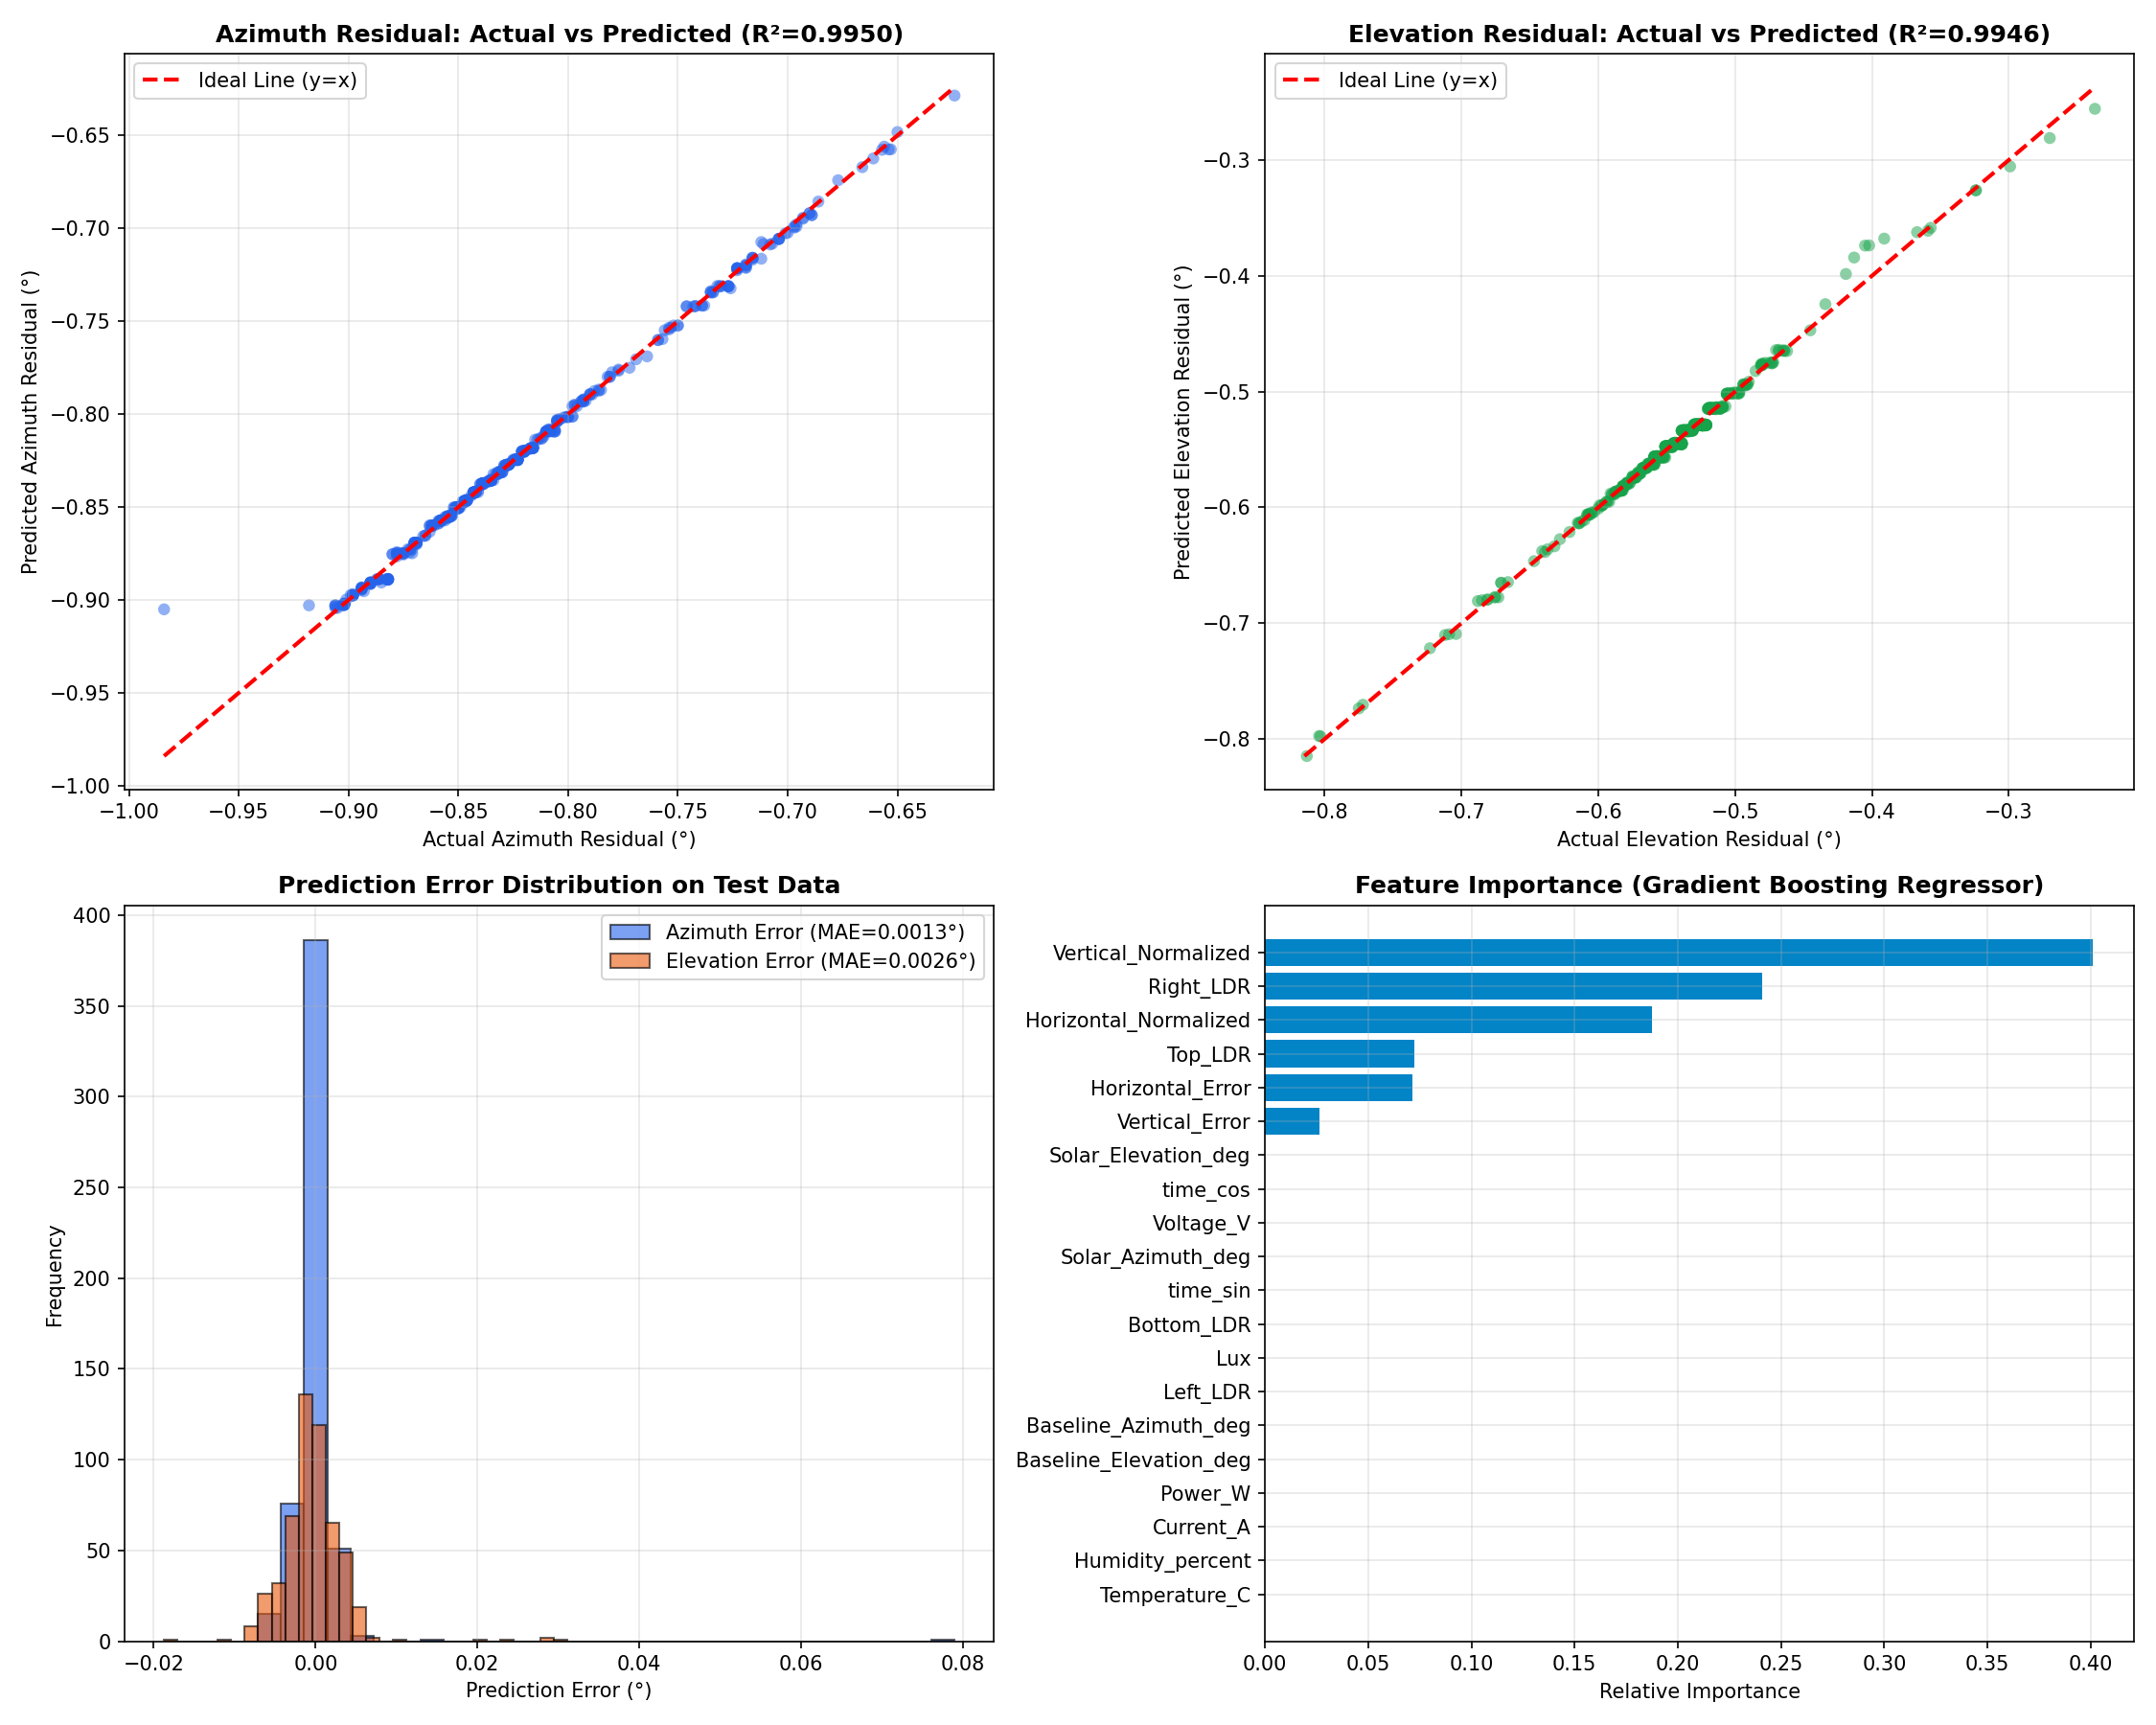

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.32, wspace=0.25)

# 1. Actual vs Predicted Azimuth Residual
axes[0, 0].scatter(y_test.iloc[:, 0], test_preds[:, 0], alpha=0.5, color='#2563eb', edgecolors='none')
az_lims = [min(y_test.iloc[:, 0].min(), test_preds[:, 0].min()), max(y_test.iloc[:, 0].max(), test_preds[:, 0].max())]
axes[0, 0].plot(az_lims, az_lims, 'r--', lw=2, label='Ideal Line (y=x)')
axes[0, 0].set_title(f'Azimuth Residual: Actual vs Predicted (R²={test_az_r2:.4f})', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Actual Azimuth Residual (°)')
axes[0, 0].set_ylabel('Predicted Azimuth Residual (°)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Actual vs Predicted Elevation Residual
axes[0, 1].scatter(y_test.iloc[:, 1], test_preds[:, 1], alpha=0.5, color='#16a34a', edgecolors='none')
el_lims = [min(y_test.iloc[:, 1].min(), test_preds[:, 1].min()), max(y_test.iloc[:, 1].max(), test_preds[:, 1].max())]
axes[0, 1].plot(el_lims, el_lims, 'r--', lw=2, label='Ideal Line (y=x)')
axes[0, 1].set_title(f'Elevation Residual: Actual vs Predicted (R²={test_el_r2:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Actual Elevation Residual (°)')
axes[0, 1].set_ylabel('Predicted Elevation Residual (°)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Prediction Error Distribution
az_err = test_preds[:, 0] - y_test.iloc[:, 0].values
el_err = test_preds[:, 1] - y_test.iloc[:, 1].values
axes[1, 0].hist(az_err, bins=30, alpha=0.6, color='#2563eb', label=f'Azimuth Error (MAE={test_az_mae:.4f}°)', edgecolor='black')
axes[1, 0].hist(el_err, bins=30, alpha=0.6, color='#ea580c', label=f'Elevation Error (MAE={test_el_mae:.4f}°)', edgecolor='black')
axes[1, 0].set_title('Prediction Error Distribution on Test Data', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Prediction Error (°)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Feature Importance
if hasattr(final_model, 'estimators_'):
    importances = np.mean([est.feature_importances_ for est in final_model.estimators_], axis=0)
elif hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
else:
    importances = np.zeros(len(feature_cols))

feat_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances}).sort_values(by='Importance', ascending=True)
axes[1, 1].barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='#0284c7')
axes[1, 1].set_title(f'Feature Importance ({best_model_name})', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Relative Importance')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation_plots.png', dpi=300)
plt.show()


### Step 8: Example Predictions
Displaying formatted sample predictions comparing Ground Truth vs Model Predictions.


In [9]:
print("Sample Predictions on Unseen Test Telemetry:")
print("-" * 50)

for i in range(5):
    act_az = y_test.iloc[i, 0]
    pred_az = test_preds[i, 0]
    act_el = y_test.iloc[i, 1]
    pred_el = test_preds[i, 1]
    
    print(f"Sample #{i + 1}:")
    print(f"  Actual Azimuth Residual:    {act_az:+.2f}°")
    print(f"  Predicted Azimuth Residual: {pred_az:+.2f}°")
    print(f"  Actual Elevation Residual:  {act_el:+.2f}°")
    print(f"  Predicted Elevation Residual: {pred_el:+.2f}°")
    print("-" * 50)


Sample Predictions on Unseen Test Telemetry:
--------------------------------------------------
Sample #1:
  Actual Azimuth Residual:    -0.84°
  Predicted Azimuth Residual: -0.84°
  Actual Elevation Residual:  -0.56°
  Predicted Elevation Residual: -0.56°
--------------------------------------------------
Sample #2:
  Actual Azimuth Residual:    -0.86°
  Predicted Azimuth Residual: -0.86°
  Actual Elevation Residual:  -0.58°
  Predicted Elevation Residual: -0.59°
--------------------------------------------------
Sample #3:
  Actual Azimuth Residual:    -0.85°
  Predicted Azimuth Residual: -0.85°
  Actual Elevation Residual:  -0.61°
  Predicted Elevation Residual: -0.61°
--------------------------------------------------
Sample #4:
  Actual Azimuth Residual:    -0.83°
  Predicted Azimuth Residual: -0.83°
  Actual Elevation Residual:  -0.57°
  Predicted Elevation Residual: -0.57°
--------------------------------------------------
Sample #5:
  Actual Azimuth Residual:    -0.81°
  Predic

### Step 9: Save Trained Model, Features, and Predictions
- `solar_tracker_model.pkl`
- `features.pkl`
- `test_predictions.csv`


In [10]:
# 1. Save model
model_filename = "solar_tracker_model.pkl"
joblib.dump(final_model, model_filename)

# 2. Save features list
features_filename = "features.pkl"
joblib.dump(feature_cols, features_filename)

# 3. Save test predictions CSV
test_results_df = test_df.copy()
test_results_df['predicted_azimuth_residual_deg'] = test_preds[:, 0]
test_results_df['predicted_elevation_residual_deg'] = test_preds[:, 1]
test_results_df['azimuth_residual_error'] = test_preds[:, 0] - y_test.iloc[:, 0].values
test_results_df['elevation_residual_error'] = test_preds[:, 1] - y_test.iloc[:, 1].values

predictions_csv_filename = "test_predictions.csv"
test_results_df.to_csv(predictions_csv_filename, index=False)

print(f"✓ Model saved as:          {model_filename}")
print(f"✓ Feature list saved as:   {features_filename}")
print(f"✓ Test predictions saved:  {predictions_csv_filename}")


✓ Model saved as:          solar_tracker_model.pkl
✓ Feature list saved as:   features.pkl
✓ Test predictions saved:  test_predictions.csv


### Step 10: Final Training Summary


In [11]:
print("MODEL TRAINING COMPLETE")
print("=" * 45)
print(f"best model:       {best_model_name}")
print(f"azimuth MAE:      {test_az_mae:.4f}°")
print(f"elevation MAE:    {test_el_mae:.4f}°")
print(f"azimuth RMSE:     {test_az_rmse:.4f}°")
print(f"elevation RMSE:   {test_el_rmse:.4f}°")
print(f"azimuth R²:       {test_az_r2:.4f}")
print(f"elevation R²:     {test_el_r2:.4f}")
print(f"saved model filename: {model_filename}")
print(f"accuracy-like percentage: {accuracy_comb_pct:.2f}% (approx error-based score)")
print("=" * 45)


MODEL TRAINING COMPLETE
best model:       Gradient Boosting Regressor
azimuth MAE:      0.0013°
elevation MAE:    0.0026°
azimuth RMSE:     0.0039°
elevation RMSE:   0.0040°
azimuth R²:       0.9950
elevation R²:     0.9946
saved model filename: solar_tracker_model.pkl
accuracy-like percentage: 99.71% (approx error-based score)


## Real-Time Solar Tracking Deployment Architecture

```
[4x LDR + Solar Ephemeris + INA219 + DHT22 Sensors]
                    │
                    ▼ (Every 100-500ms)
        [Sensor Feature Vector (20 Features)]
                    │
                    ▼
     [Trained ML Model (solar_tracker_model.pkl)]
                    │
       ┌────────────┴────────────┐
       ▼                         ▼
[Azimuth Residual (ΔAz°)]   [Elevation Residual (ΔEl°)]
       │                         │
       ▼                         ▼
[Final Azimuth Target =     [Final Elevation Target =
 Base_Az + ΔAz]              Base_El + ΔEl]
       │                         │
       └────────────┬────────────┘
                    ▼
 [Stepper / Servo Closed-Loop Motor Control]
                    │
                    ▼
       [Optimal Perpendicular Sun Alignment]
```

### Real-time Deployment Steps:
1. **Sensor Ingestion**: Microcontroller (ESP32 / Raspberry Pi) reads LDR sensors, calculates solar position (NREL SPA / baseline ephemeris), and samples temperature, voltage, and current.
2. **Feature Extraction**: Computes normalized differences, errors, and sinusoidal temporal cyclical embeddings matching the saved `features.pkl`.
3. **ML Inference**: `final_model.predict(features)` estimates the residual tracking errors caused by structural misalignment, panel tilt tolerances, or diffuse cloud refraction.
4. **Correction Calculation**: Correction angles are added to the theoretical astronomical baseline angles.
5. **Motor Actuation**: Pulse-width modulation (PWM) commands drive azimuth stepper motors and elevation servo actuators directly to zero-out physical tracking error.
